# Day 07 — Decision Tree & Random Forest

Student Pass/Fail Prediction using Scikit-Learn

## 1. Decision Tree

A Decision Tree makes predictions by asking a sequence of questions and following branches.

- Root Node
- Decision Node
- Branch
- Leaf Node

## 2. Gini Impurity

Gini Impurity measures how mixed the classes are in a node. A node containing only one class is pure.

## 3. Overfitting

A very complex Decision Tree can memorize training data instead of learning patterns that generalize. `max_depth` can help control tree complexity.

## 4. Random Forest

Random Forest is an ensemble algorithm that combines multiple Decision Trees. For classification, trees commonly contribute through majority voting.

## 5. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


## 6. Create Student Pass/Fail Dataset

In [2]:
data = {
    "Hours": [1,2,3,4,5,6,7,8,9,10],
    "Attendance": [50,55,60,65,70,75,80,85,90,95],
    "Result": [0,0,0,1,1,1,1,1,1,1]
}

df = pd.DataFrame(data)

print(df)


   Hours  Attendance  Result
0      1          50       0
1      2          55       0
2      3          60       0
3      4          65       1
4      5          70       1
5      6          75       1
6      7          80       1
7      8          85       1
8      9          90       1
9     10          95       1


## 7. Inspect Dataset

In [3]:
print(df.head())
print("Shape:", df.shape)
print(df.describe())


   Hours  Attendance  Result
0      1          50       0
1      2          55       0
2      3          60       0
3      4          65       1
4      5          70       1
Shape: (10, 3)
          Hours  Attendance     Result
count  10.00000   10.000000  10.000000
mean    5.50000   72.500000   0.700000
std     3.02765   15.138252   0.483046
min     1.00000   50.000000   0.000000
25%     3.25000   61.250000   0.250000
50%     5.50000   72.500000   1.000000
75%     7.75000   83.750000   1.000000
max    10.00000   95.000000   1.000000


## 8. Separate Features and Target

In [4]:
X = df[["Hours", "Attendance"]]
y = df["Result"]

print("Features:")
print(X)

print("\nTarget:")
print(y)


Features:
   Hours  Attendance
0      1          50
1      2          55
2      3          60
3      4          65
4      5          70
5      6          75
6      7          80
7      8          85
8      9          90
9     10          95

Target:
0    0
1    0
2    0
3    1
4    1
5    1
6    1
7    1
8    1
9    1
Name: Result, dtype: int64


## 9. Train-Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Features:")
print(X_train)

print("\nTesting Features:")
print(X_test)


Training Features:
   Hours  Attendance
5      6          75
0      1          50
7      8          85
2      3          60
9     10          95
4      5          70
3      4          65
6      7          80

Testing Features:
   Hours  Attendance
8      9          90
1      2          55


## 10. Create Decision Tree

In [6]:
model = DecisionTreeClassifier(
    random_state=42
)

print(model)


DecisionTreeClassifier(random_state=42)


## 11. Train Decision Tree

In [7]:
model.fit(X_train, y_train)

print("Decision Tree training completed.")


Decision Tree training completed.


## 12. Predict Test Data

In [8]:
y_pred = model.predict(X_test)

print("Actual:")
print(y_test.values)

print("\nPredicted:")
print(y_pred)


Actual:
[1 0]

Predicted:
[1 0]


## 13. Calculate Accuracy

In [9]:
accuracy = accuracy_score(y_test, y_pred)

print("Decision Tree Accuracy:", accuracy * 100, "%")


Decision Tree Accuracy: 100.0 %


## 14. Predict a New Student

In [10]:
new_student = pd.DataFrame({
    "Hours": [6],
    "Attendance": [78]
})

prediction = model.predict(new_student)

if prediction[0] == 1:
    print("Result: PASS")
else:
    print("Result: FAIL")


Result: PASS


## 15. Visualize Decision Tree

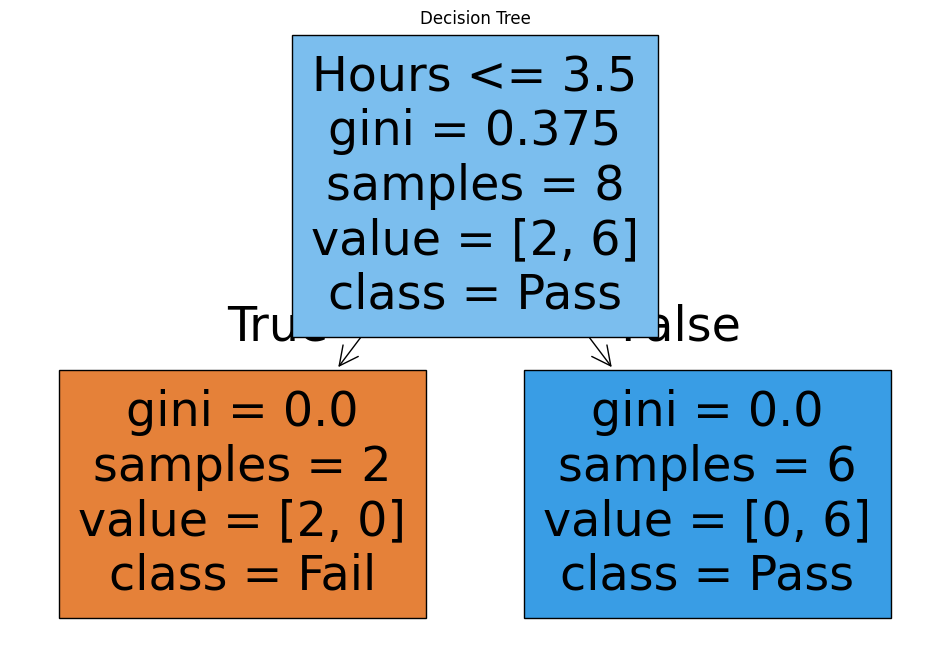

In [11]:
plt.figure(figsize=(12, 8))

plot_tree(
    model,
    feature_names=["Hours", "Attendance"],
    class_names=["Fail", "Pass"],
    filled=True
)

plt.title("Decision Tree")
plt.show()


## 16. Control Tree Depth

In [12]:
model_depth_3 = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

model_depth_3.fit(X_train, y_train)

predictions = model_depth_3.predict(X_test)

score = accuracy_score(y_test, predictions)

print("Accuracy:", score * 100, "%")


Accuracy: 100.0 %


## 17. Compare Different Tree Depths

In [13]:
for depth in [1, 2, 3, 4, 5]:
    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    tree.fit(X_train, y_train)
    predictions = tree.predict(X_test)

    score = accuracy_score(y_test, predictions)

    print(
        "max_depth:", depth,
        "| Accuracy:", score * 100, "%"
    )


max_depth: 1 | Accuracy: 100.0 %
max_depth: 2 | Accuracy: 100.0 %
max_depth: 3 | Accuracy: 100.0 %
max_depth: 4 | Accuracy: 100.0 %
max_depth: 5 | Accuracy: 100.0 %


## 18. Create Random Forest

In [14]:
forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

print(forest)


RandomForestClassifier(random_state=42)


## 19. Train Random Forest

In [15]:
forest.fit(X_train, y_train)

print("Random Forest training completed.")


Random Forest training completed.


## 20. Predict with Random Forest

In [16]:
forest_pred = forest.predict(X_test)

print("Actual:")
print(y_test.values)

print("\nPredicted:")
print(forest_pred)


Actual:
[1 0]

Predicted:
[1 0]


## 21. Random Forest Accuracy

In [17]:
forest_accuracy = accuracy_score(
    y_test,
    forest_pred
)

print(
    "Random Forest Accuracy:",
    forest_accuracy * 100,
    "%"
)


Random Forest Accuracy: 100.0 %


## 22. Predict New Student with Random Forest

In [18]:
prediction = forest.predict(new_student)

if prediction[0] == 1:
    print("Result: PASS")
else:
    print("Result: FAIL")


Result: PASS


## 23. Random Forest Probability

In [19]:
probability = forest.predict_proba(new_student)

print("Fail Probability:", probability[0][0])
print("Pass Probability:", probability[0][1])


Fail Probability: 0.0
Pass Probability: 1.0


## 24. Compare Number of Trees

In [20]:
for n in [10, 50, 100]:
    forest_model = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )

    forest_model.fit(X_train, y_train)
    predictions = forest_model.predict(X_test)

    score = accuracy_score(y_test, predictions)

    print(
        "n_estimators:", n,
        "| Accuracy:", score * 100, "%"
    )


n_estimators: 10 | Accuracy: 100.0 %
n_estimators: 50 | Accuracy: 100.0 %
n_estimators: 100 | Accuracy: 100.0 %


## 25. Compare Logistic Regression, Decision Tree and Random Forest

In [21]:
logistic = LogisticRegression(max_iter=1000)

tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

logistic.fit(X_train, y_train)
tree.fit(X_train, y_train)
forest.fit(X_train, y_train)

logistic_pred = logistic.predict(X_test)
tree_pred = tree.predict(X_test)
forest_pred = forest.predict(X_test)

print(
    "Logistic Regression:",
    accuracy_score(y_test, logistic_pred) * 100,
    "%"
)

print(
    "Decision Tree:",
    accuracy_score(y_test, tree_pred) * 100,
    "%"
)

print(
    "Random Forest:",
    accuracy_score(y_test, forest_pred) * 100,
    "%"
)


Logistic Regression: 100.0 %
Decision Tree: 100.0 %
Random Forest: 100.0 %


## 26. Complete Decision Tree Project

Decision Tree Accuracy: 100.0 %
Result: PASS


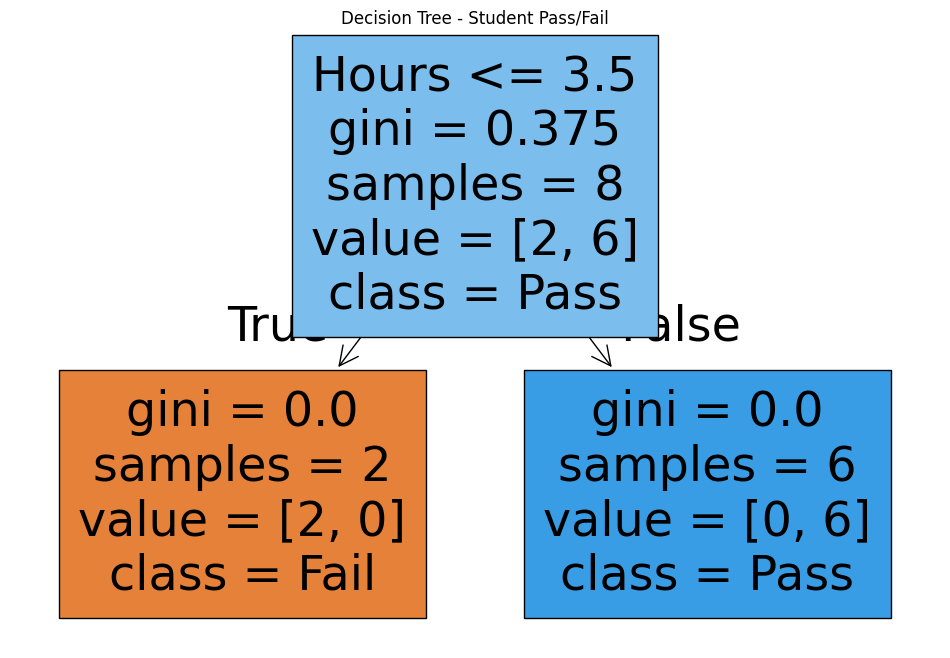

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

data = {
    "Hours": [1,2,3,4,5,6,7,8,9,10],
    "Attendance": [50,55,60,65,70,75,80,85,90,95],
    "Result": [0,0,0,1,1,1,1,1,1,1]
}

df = pd.DataFrame(data)

X = df[["Hours", "Attendance"]]
y = df["Result"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(
    "Decision Tree Accuracy:",
    accuracy_score(y_test, y_pred) * 100,
    "%"
)

new_student = pd.DataFrame({
    "Hours": [6],
    "Attendance": [78]
})

prediction = model.predict(new_student)

if prediction[0] == 1:
    print("Result: PASS")
else:
    print("Result: FAIL")

plt.figure(figsize=(12, 8))

plot_tree(
    model,
    feature_names=["Hours", "Attendance"],
    class_names=["Fail", "Pass"],
    filled=True
)

plt.title("Decision Tree - Student Pass/Fail")
plt.show()


## 27. Complete Random Forest Project

In [23]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

data = {
    "Hours": [1,2,3,4,5,6,7,8,9,10],
    "Attendance": [50,55,60,65,70,75,80,85,90,95],
    "Result": [0,0,0,1,1,1,1,1,1,1]
}

df = pd.DataFrame(data)

X = df[["Hours", "Attendance"]]
y = df["Result"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(
    "Random Forest Accuracy:",
    accuracy_score(y_test, y_pred) * 100,
    "%"
)

new_student = pd.DataFrame({
    "Hours": [6],
    "Attendance": [78]
})

prediction = model.predict(new_student)
probability = model.predict_proba(new_student)

if prediction[0] == 1:
    print("Result: PASS")
else:
    print("Result: FAIL")

print("Fail Probability:", probability[0][0])
print("Pass Probability:", probability[0][1])


Random Forest Accuracy: 100.0 %
Result: PASS
Fail Probability: 0.0
Pass Probability: 1.0


# 🎯 Day 7 Final Flow

`Dataset → Features + Target → Train/Test Split → Decision Tree / Random Forest → Training → Prediction → Evaluation`

### Next: Day 8
**Unsupervised Learning + K-Means Clustering**
